In [1]:
from tripod import plot
import matplotlib

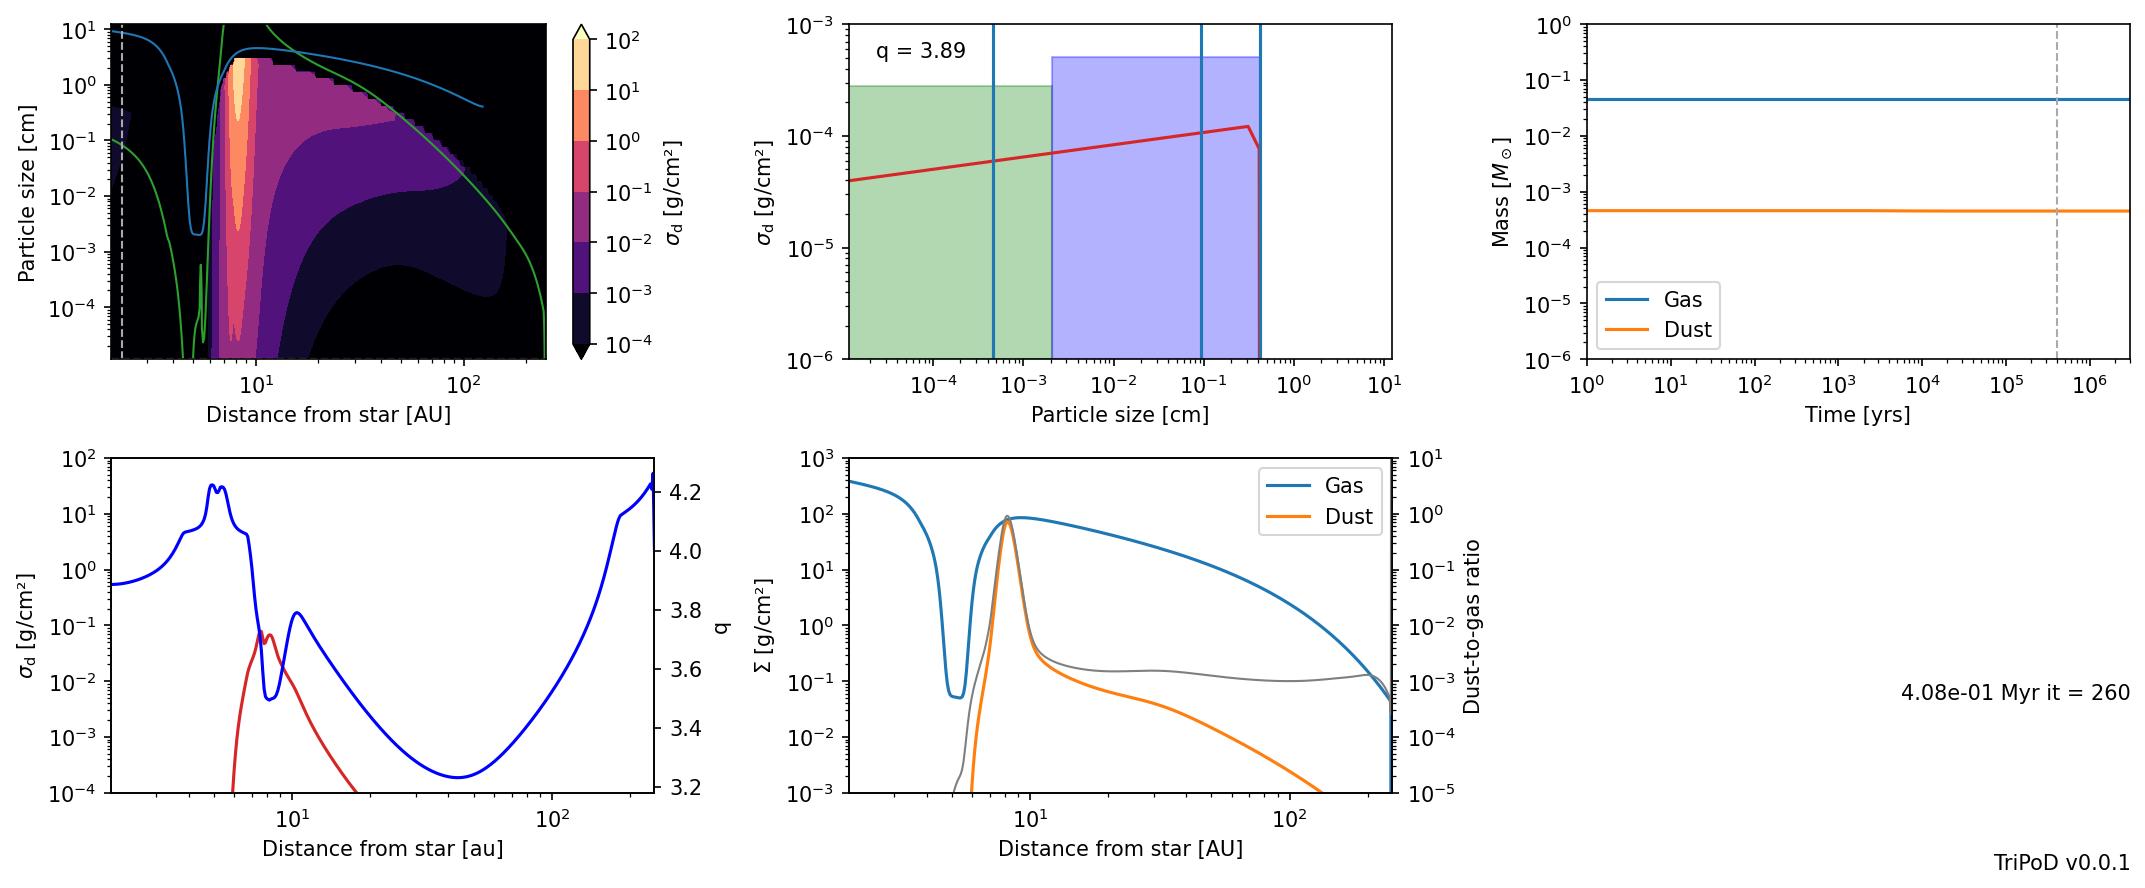

In [9]:
plot.panel("data",it =260,ir =10,show_limits=True)

In [4]:
from tripod import hdf5writer
import matplotlib.pyplot as plt
import dustpy.constants as c
import numpy as np 

In [5]:
wrtr = hdf5writer()
data = wrtr.read.all()
print("N_t",len(data.t),"t_last", data.t[-1]/c.year/1e6)

N_t 301 t_last 2.999999996616433


(6.0, 6.5)

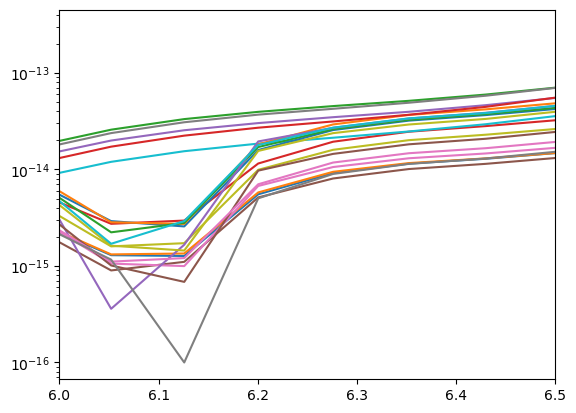

In [45]:
plt.figure()
for it in range(len(data.t))[230:250]:   
    plt.plot(data.grid.r[it,...]/c.au,data.dust.S.ext[it,:,1]+1e-16)
plt.yscale("log")
plt.xlim(6,6.5)



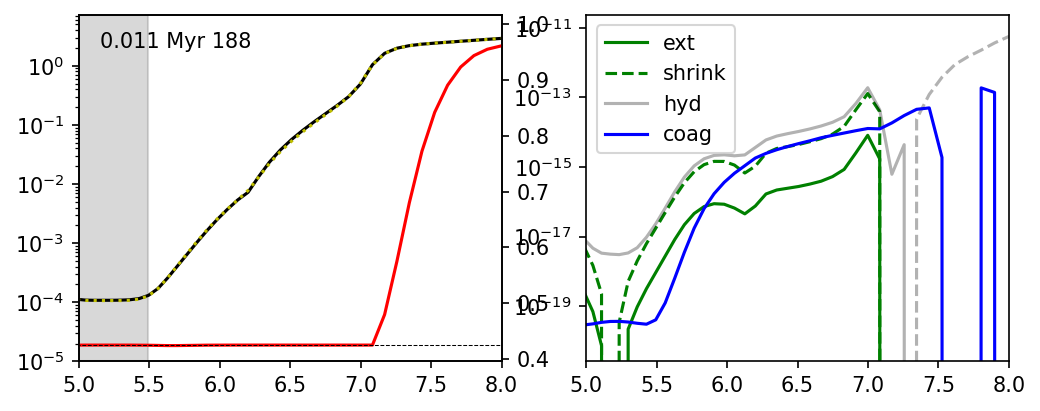

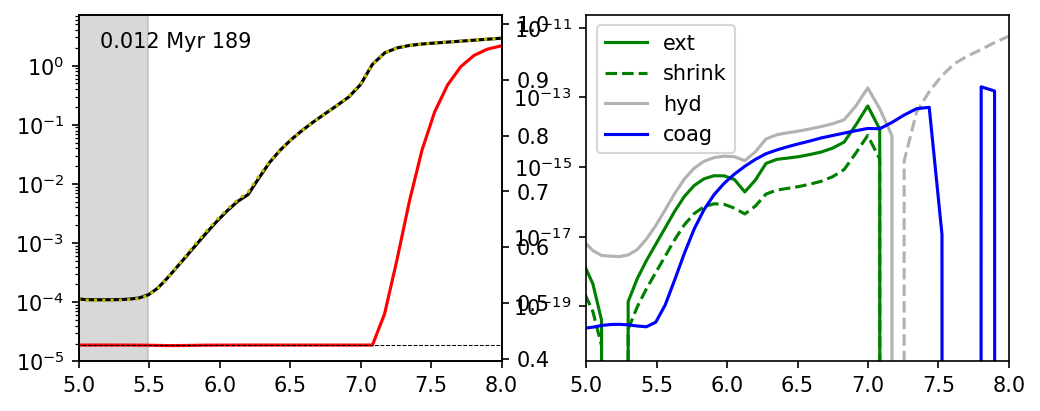

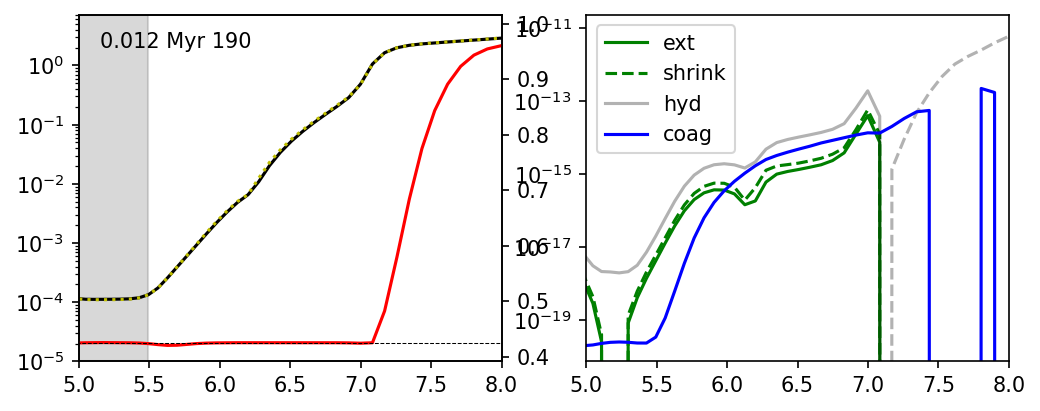

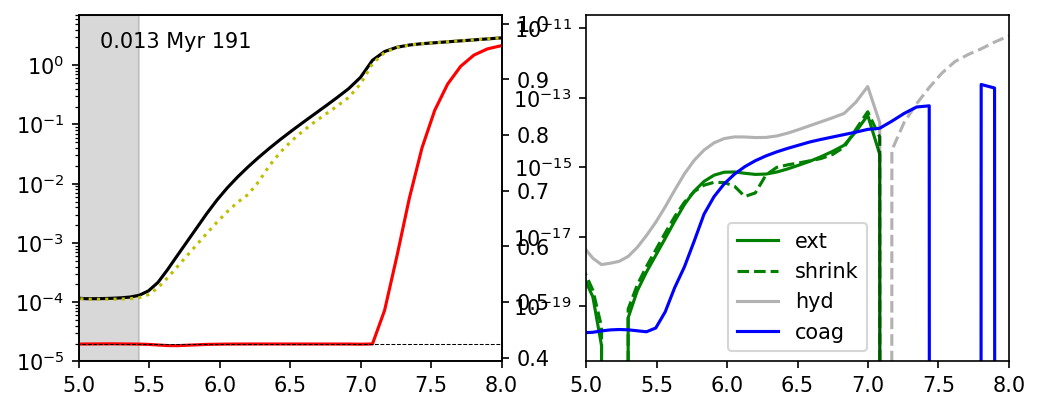

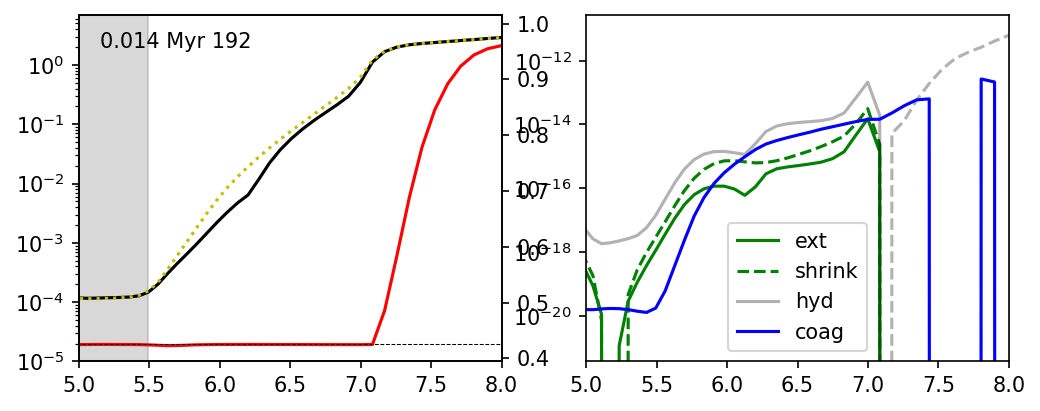

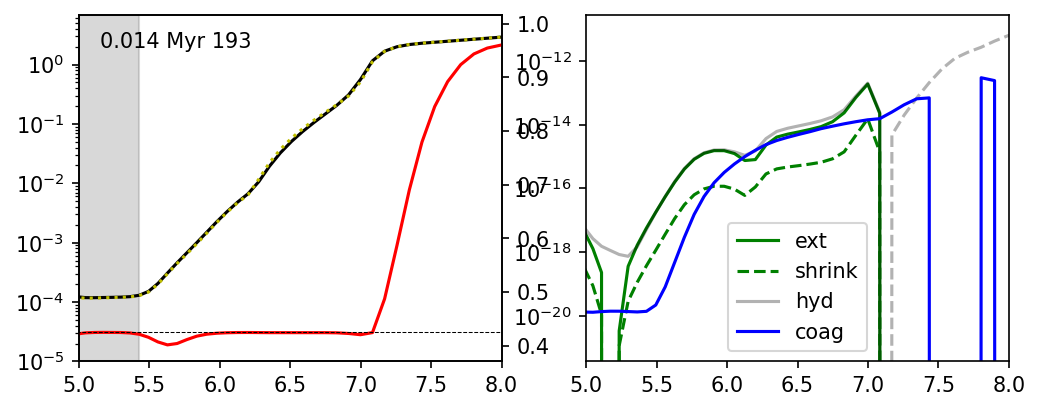

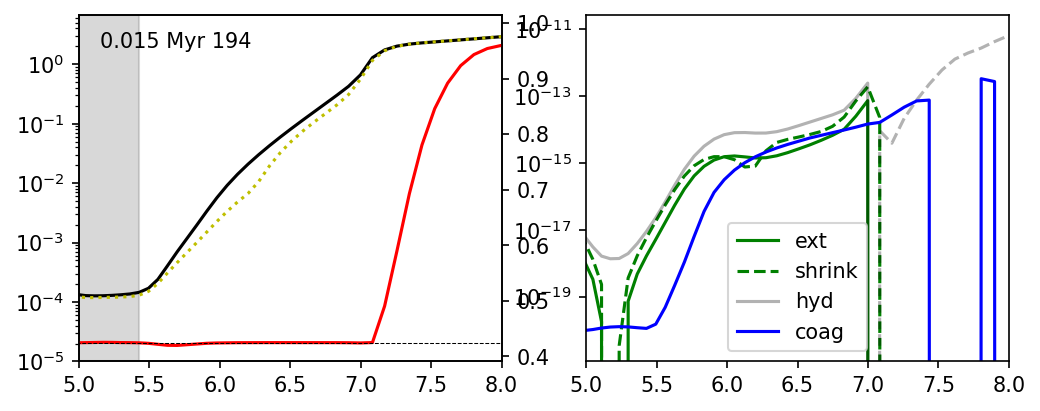

In [52]:
list = range(188,195)
for it in list:
    f,axs = plt.subplots(1, 2, figsize=(8, 3), dpi=150)
    ax = axs[0]
    ax2 = axs[1]
    #time = 4e5*c.year
    #it = np.abs(data.t - time).argmin()
    #it = it-1
    ax.text(0.05,0.95,"%.3f Myr %i"%(data.t[it]/c.year/1e6,it),transform=ax.transAxes,va = "top",ha="left")
    ax.plot(data.grid.r[it,...]/c.au,abs(data.dust.s.max[it,:]),'k')
    ax.plot(data.grid.r[it,...]/c.au,abs(data.dust.s.max[it-1,:]),'y:')
    ax3 = ax.twinx()
    ax3.plot(data.grid.r[it,...]/c.au,abs(data.dust.Sigma[it,:,1])/(data.dust.Sigma[it,...].sum(-1)),'r')
    ax3.plot(data.grid.r[it,...]/c.au,0.425*np.ones_like(data.grid.r[it,...]) ,'k--',linewidth = 0.5)
    #ax.plot(data.grid.r[it,...]/c.au,(data.dust.s.sdot_coag[it]),'b')
    ax.set_ylim(1e-5)
    #ax2.plot(data.grid.r[it,...]/c.au,-data.dust.S.tot[it,:,1],"--m")
    ax2.plot(data.grid.r[it,...]/c.au,data.dust.S.ext[it,:,1],"g",label ="ext")
    ax2.plot(data.grid.r[it,...]/c.au,data.dust.S.ext[it-1,:,1],"g--",label = "shrink")
    ax2.plot(data.grid.r[it,...]/c.au,-data.dust.S.hyd[it,:,1],"k",label = "hyd",alpha = 0.3)
    ax2.plot(data.grid.r[it,...]/c.au,data.dust.S.hyd[it,:,1],"k--",alpha = 0.3)
    #ax2.plot(data.grid.r[it,...]/c.au,data.dust.S.tot[it,:,1],"m",label = "tot")

    ax2.plot(data.grid.r[it,...]/c.au,data.dust.S.coag[it,:,1],"b",label ="coag")
    ax2.legend()

    segments = []
    true_indices = data.dust.s.max[it,...] <= 1.5e-4
    true_indices = np.where(true_indices)[0]
    if len(true_indices) > 0:
        start = true_indices[0]
        for i in range(1, len(true_indices)):
            if true_indices[i] != true_indices[i - 1] +1:
                segments.append((data.grid.r[it,start]/c.au, data.grid.r[it,true_indices[i - 1]]/c.au))
                start = true_indices[i]

    segments.append((data.grid.r[it,start]/c.au, data.grid.r[it,true_indices[-1]]/c.au))


    # Shade the continuous "True" regions
    for start, end in segments:
        ax.axvspan(start, end, color='gray', alpha=0.3)

    for ax in axs:
        ax.set_xlim(5,8)
        ax.set_yscale("log")


In [14]:
it

np.int64(259)

(2.0, 8.0)

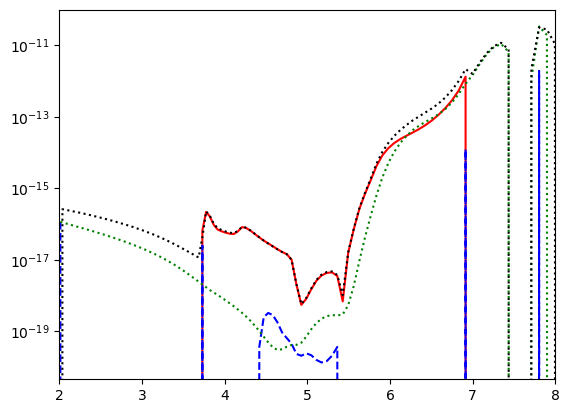

In [63]:
it = np.abs(data.t - time).argmin()
plt.plot(data.grid.r[it,...]/c.au,(data.dust.S.ext[it,:,1]),'r')
plt.plot(data.grid.r[it,...]/c.au,(data.dust.S.tot[it,:,1]),'b--')
plt.plot(data.grid.r[it,...]/c.au,(data.dust.S.coag[it,:,1]),'g:')
plt.plot(data.grid.r[it,...]/c.au,-(data.dust.S.hyd[it,:,1]),'k:')
plt.yscale("log")
plt.xlim(2,8)



(2.0, 8.0)

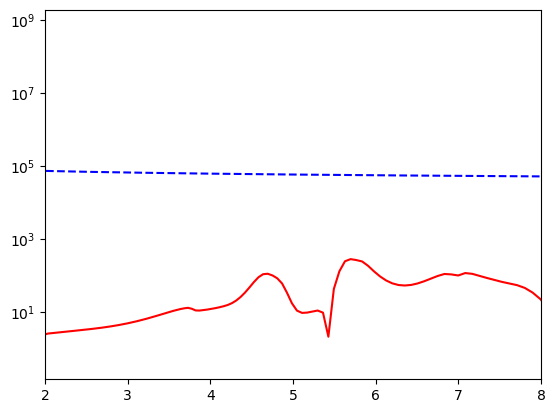

In [74]:
it = np.abs(data.t - time).argmin()
plt.plot(data.grid.r[it,...]/c.au,abs(data.dust.v.rad[it,:,1]),'r')
plt.plot(data.grid.r[it,...]/c.au,abs(data.gas.cs[it,:]),'b--')

plt.yscale("log")
plt.xlim(2,8)


(2.0, 8.0)

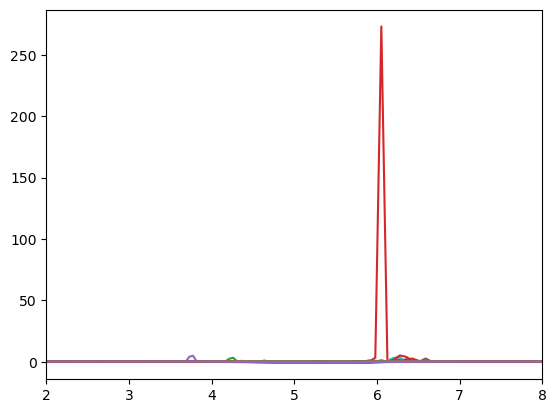

In [6]:
plt.figure()
for it in range(len(data.t))[:]:   
    xi = np.log(data.dust.Sigma[it,:,1]/data.dust.Sigma[it,:,0])/np.log(data.dust.s.max[it,:]/data.dust.s.min[it,:])
    plt.plot(data.grid.r[it,...]/c.au,xi)
    
plt.xlim(2,8)

(2.0, 8.0)

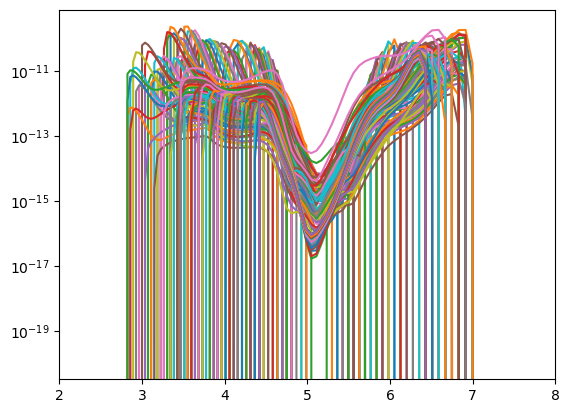

In [5]:
plt.figure()
for it in range(len(data.t))[:]:   
    plt.plot(data.grid.r[it,...]/c.au,-data.dust.s.sdot_shrink[it,:])
plt.yscale("log")
plt.xlim(2,8)

In [23]:
data.t[-1]/c.year

np.float64(253.83413866928242)

(2.0, 8.0)

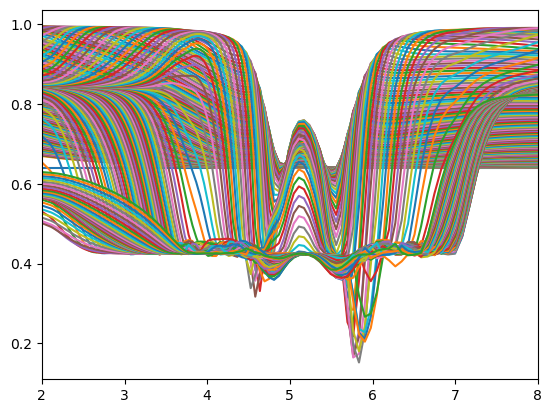

In [26]:
plt.figure()
for it in range(len(data.t))[:-10]:   
    plt.plot(data.grid.r[it,...]/c.au,data.dust.Sigma[it,:,1]/data.dust.Sigma[it,...].sum(-1))
plt.xlim(2,8)


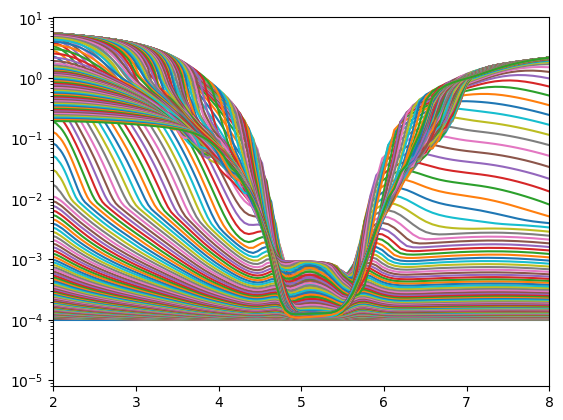

In [24]:
plt.figure()
for it in range(len(data.t))[:]:   
    plt.plot(data.grid.r[it,...]/c.au,data.dust.s.max[it,:])
plt.xlim(2,8)
plt.yscale("log")

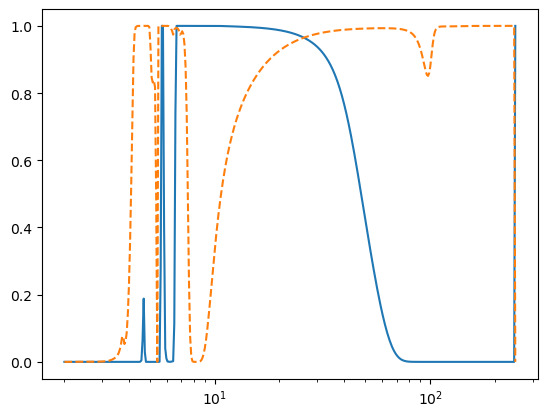

In [20]:
plt.figure()
time = 0.1*1e6*c.year
it = np.abs(data.t - time).argmin()

plt.plot(data.grid.r[it,...]/c.au,data.dust.p.frag[it,:])
plt.plot(data.grid.r[it,...]/c.au,data.dust.p.drift[it,:],"--")



plt.xscale("log")

In [15]:
from tripod.utils import get_q

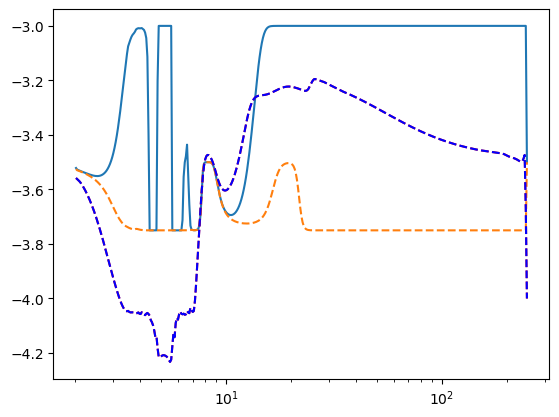

In [17]:
plt.figure()
time = 0.1e5*c.year
it = np.abs(data.t - time).argmin()

plt.plot(data.grid.r[it,...]/c.au,data.dust.q.eff[it,:])
plt.plot(data.grid.r[it,...]/c.au,data.dust.q.frag[it,:],"--")
plt.plot(data.grid.r[it,...]/c.au,data.dust.qrec[it,:],"r--")
q_2 = get_q(data.dust.Sigma[it,...],data.dust.s.min[it,...],data.dust.s.max[it,...])
plt.plot(data.grid.r[it,...]/c.au,-q_2,"b--")

plt.xscale("log")

278


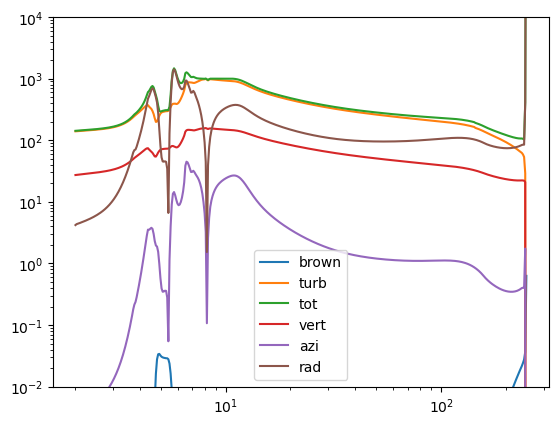

In [68]:
time = 1e6*c.year
i = -2
j = -1
it = np.abs(data.t - time).argmin()
print(it)
plt.figure()
plt.plot(data.grid.r[it,...]/c.au,data.dust.v.rel.brown[it,:,j,i],label ="brown")
plt.plot(data.grid.r[it,...]/c.au,data.dust.v.rel.turb[it,:,j,i],label = "turb")
plt.plot(data.grid.r[it,...]/c.au,data.dust.v.rel.tot[it,:,j,i],label = "tot")
plt.plot(data.grid.r[it,...]/c.au,data.dust.v.rel.vert[it,:,j,i],label = "vert")
plt.plot(data.grid.r[it,...]/c.au,data.dust.v.rel.azi[it,:,j,i],label = "azi")
plt.plot(data.grid.r[it,...]/c.au,data.dust.v.rel.rad[it,:,j,i],label = "rad")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.ylim(1e-2,1e4)
plt.show()


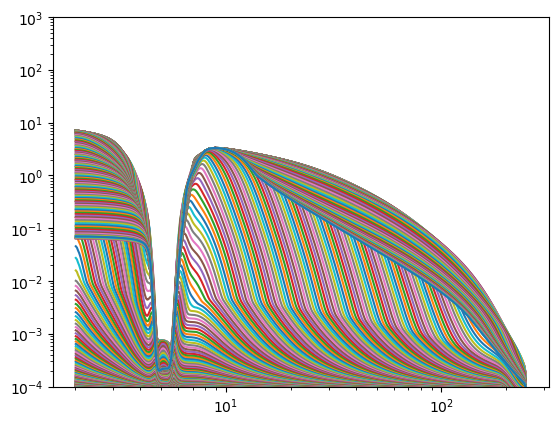

In [6]:
plt.figure()
time = 0.4e6*c.year
it = np.abs(data.t - time).argmin()
for it in range(len(data.t)):
    plt.loglog(data.grid.r[it,:]/c.au,data.dust.s.max[it,:])
    
plt.ylim(1e-4,1e3)
plt.show()


In [7]:
import pyPLUTO as ppl 
import glob
from pathlib import Path
pl_path = '../NewTests/Duffell_alim1e-4_fcrit0425/data/'


_d = ppl.Load(0, path=str(pl_path))


PyPLUTO version: 1.0   session: Jupyter notebook or qtconsole
Load: folder ../NewTests/Duffell_alim1e-4_fcrit0425/data/,     output 0


Load: folder ../NewTests/Duffell_alim1e-4_fcrit0425/data/,     output 260
260 260


(100.0, 10000.0)

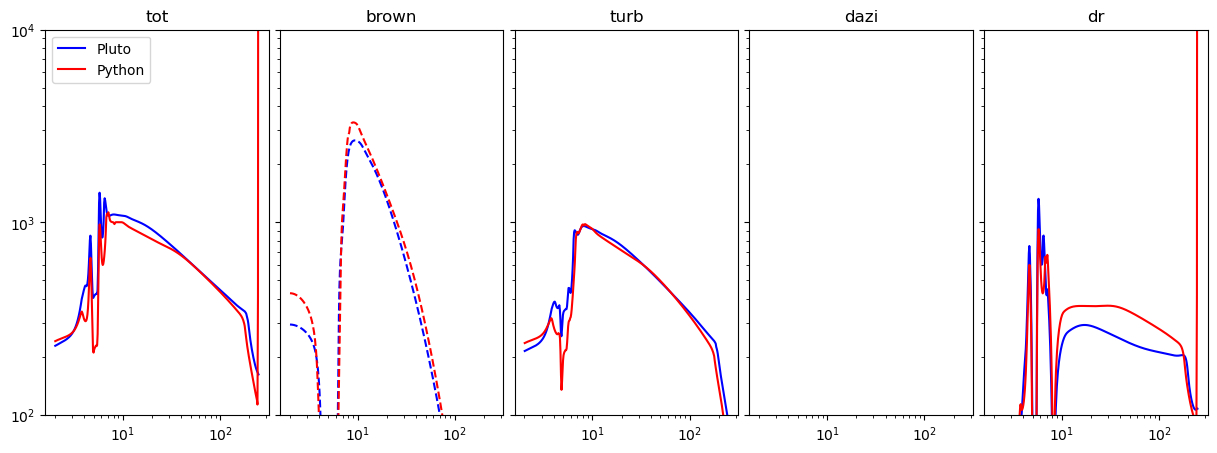

In [8]:
time = 0.4e6 *c.year

it_t =  np.abs(_d.timelist/ (2 * np.pi)*c.year  - time).argmin()

_d = ppl.Load(it_t, path=str(pl_path))
it =  np.abs(data.t - time).argmin()
print(it_t,it)
r = _d.x1
f, axs = plt.subplots(1, 5, figsize=(15., 5), gridspec_kw={'width_ratios':[1, 1, 1, 1,1], 'wspace':0.05})

dv_tot = ( _d.dvBr**2 +_d.dvdr_phi**2 + _d.dvdr_r**2 + _d.dvtr**2 + _d.dvset**2)**0.5

axs[0].set_title("tot")
axs[0].plot(r,dv_tot,"b",label="Pluto")
axs[0].plot(data.grid.r[it,...]/c.au,data.dust.v.rel.tot[it,:,-1,-2],"r",label="Python") 
axs[0].set_yscale("log")
axs[0].set_xscale("log")
axs[0].legend()

axs[1].set_title("brown")
axs[1].plot(r,_d.dvBr,"b")
a_max = _d.tr3.ravel() / _d.tr2.ravel()
axs[1].plot(r,a_max*1e3,"b--")
axs[1].plot(data.grid.r[it,...]/c.au,data.dust.v.rel.brown[it,:,-1,-2],"r") 
axs[1].plot(data.grid.r[it,...]/c.au,data.dust.s.max[it,:]*1e3,"r--") 
axs[1].set_yscale("log")
axs[1].set_xscale("log")

axs[2].set_title("turb")
axs[2].plot(r,_d.dvtr,"b")
axs[2].plot(data.grid.r[it,...]/c.au,data.dust.v.rel.turb[it,:,-1,-2],"r") 
axs[2].set_yscale("log")
axs[2].set_xscale("log")

axs[3].set_title("dazi")
dv_dr = _d.dvdr_phi
axs[3].plot(r,dv_dr,"b")
dv_dr =  data.dust.v.rel.azi[it,:,-1,-2]
axs[3].plot(data.grid.r[it,...]/c.au,dv_dr,"r") 
axs[3].set_yscale("log")
axs[3].set_xscale("log")

axs[4].set_title("dr")
dv_dr = _d.dvdr_r
axs[4].plot(r,dv_dr,"b")
dv_dr =  data.dust.v.rel.rad[it,:,-1,-2]
axs[4].plot(data.grid.r[it,...]/c.au,dv_dr,"r") 
axs[4].set_yscale("log")
axs[4].set_xscale("log")


for ax in axs:
    ax.set_ylim(1e2,1e4)

for ax in axs[1:]:
    ax.set_yticklabels([])


axs[0].set_ylim(1e2,1e4)
axs[2].set_ylim(1e2,1e4)


In [71]:
data.dust.backreaction.B

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(282, 399))

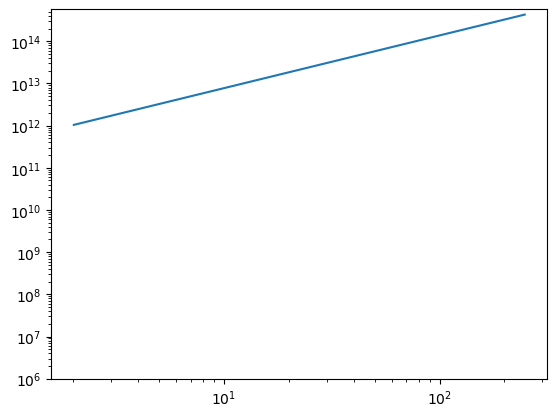

In [14]:
plt.figure()
gamma = 1.43
plt.loglog(data.grid.r[it,...]/c.au,data.gas.Hp[it,:])


plt.ylim(1e6)
plt.show()

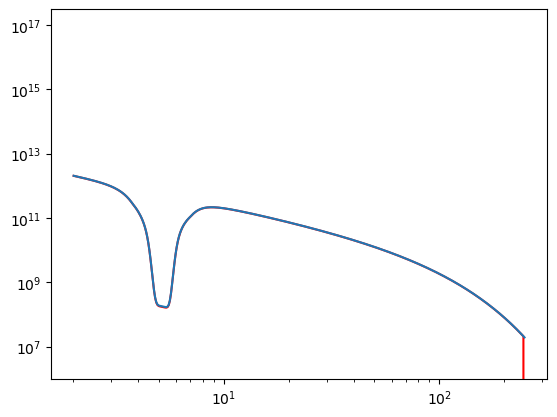

In [10]:
plt.figure()
gamma = 1.43
plt.loglog(data.grid.r[it,...]/c.au,data.gas.P[it,:]*data.gas.Hp[it,:]*(2.*np.pi)**0.5,"r")
UV = np.sqrt(c.G * c.M_sun / c.au)
UD = 733.2787923596493
p_p = _d.prs*UD*UV**2
plt.loglog(r,abs(p_p[:,0]))


plt.ylim(1e6)
plt.show()
#prs 


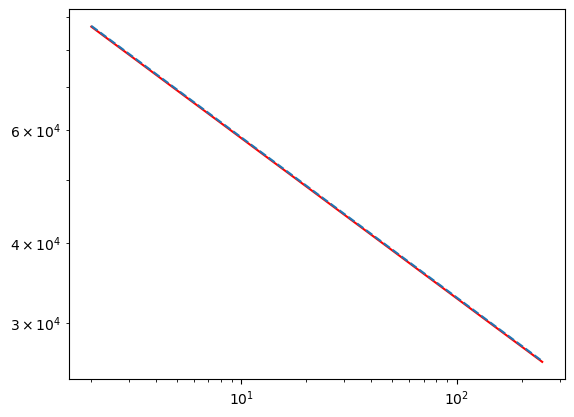

In [49]:
plt.figure()
plt.loglog(data.grid.r[it,...]/c.au,data.gas.cs[it,...] ,"r")
UV = np.sqrt(c.G * c.M_sun / c.au)
UD = 733.2787923596493
p_p = _d.prs*UD*UV**2/c.au
grad = (p_p[1:,0]-p_p[:-1,0])/(r[1:]-r[:-1])
cs = (_d.prs/_d.rho*1.43)**0.5 *UV
plt.loglog(r,cs,"--")

plt.show()
#prs 

(0.0001, np.float64(51613841.18337712))

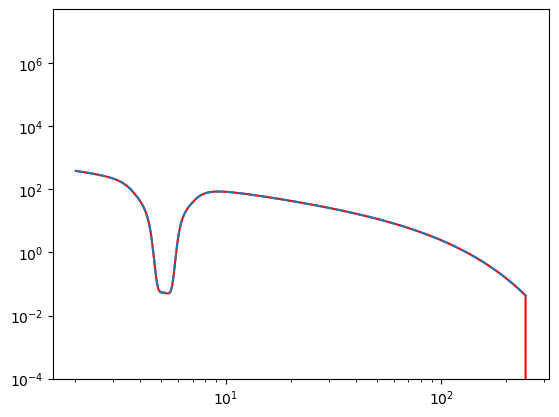

In [52]:
plt.figure()
plt.loglog(data.grid.r[it,...]/c.au,data.gas.Sigma[it,...] ,"r")
UV = np.sqrt(c.G * c.M_sun / c.au)
UD = 733.2787923596493
p_p = _d.prs*UD*UV**2/c.au
grad = (p_p[1:,0]-p_p[:-1,0])/(r[1:]-r[:-1])
cs = (_d.prs/_d.rho*1.43)**0.5 *UV
plt.loglog(r,_d.rho*UD,"--")
plt.ylim(1e-4)

In [11]:
data.gas.v.rad[it,:]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
plt.figure()
plt.loglog(data.grid.r[it,...]/c.au,data.gas.P[it,...],"r")
plt.loglog(r,_d.prs)
plt.ylim(1e-9)
plt.show()

Load: folder ../Calibration_Gap/Duffell_alim1e-4_fcrit0425/data/,     output 213
(400, 1) (399,)


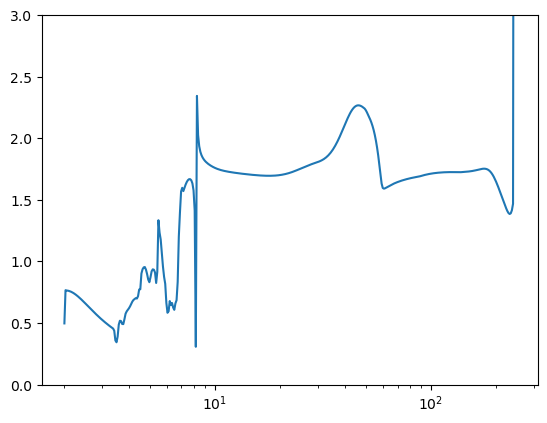

In [48]:
time = 0.04e6 *c.year

it_t =  np.abs(_d.timelist/ (2 * np.pi)*c.year  - time).argmin()
it =  np.abs(data.t - time).argmin()
_d = ppl.Load(it_t, path=str(pl_path))
print(np.shape(_d.dvdr_r),np.shape(data.dust.v.rel.rad[it,:,-1,-2]))
plt.plot(r[:-1],data.dust.v.rel.rad[it,:,-1,-2]/_d.dvdr_r[:-1,0])
plt.ylim(0,3)
plt.xscale("log")

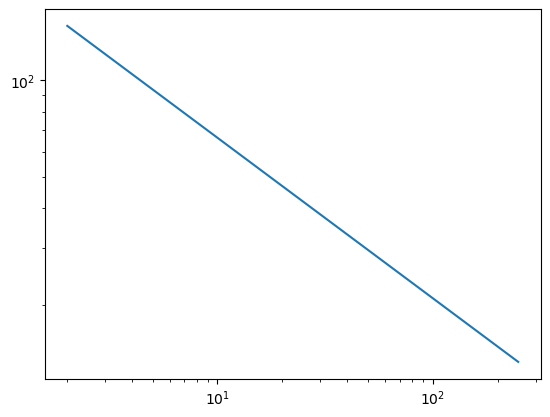

In [96]:
plt.figure()
plt.plot(data.grid.r[it,...]/c.au,data.gas.T[it,...])
plt.xscale("log")
plt.yscale("log")


In [93]:
dir(data.gas)

['Fi',
 'Hp',
 'P',
 'S',
 'Sigma',
 'SigmaFloor',
 'T',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'alpha',
 'cs',
 'eta',
 'gamma',
 'mfp',
 'mu',
 'n',
 'nu',
 'rho',
 'torque',
 'v']

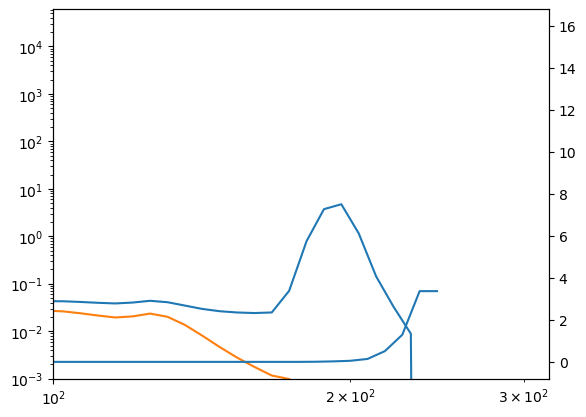

In [29]:
it = 172
plt.figure()
plt.loglog(data.grid.ri[it,:]/c.au,-(data.dust.Fi.tot[it,:,1]))
plt.loglog(data.grid.ri[it,:]/c.au,(data.dust.Fi.tot[it,:,0]))
plt.xlim(100)
plt.ylim(1e-3)
ax = plt.gca()
ax2 = ax.twinx()
ax2.plot(data.grid.r[it,:]/c.au,(data.dust.a[it,:,4]))
plt.show()

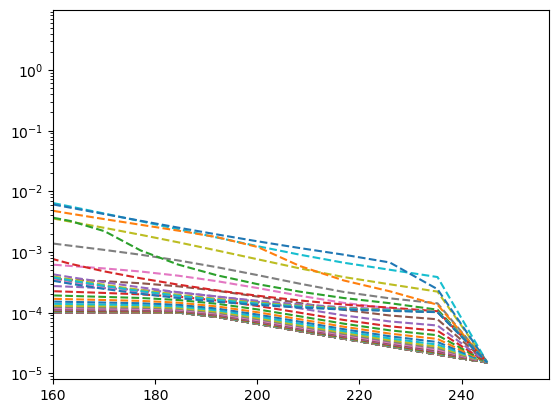

In [6]:
for it in range(len(data.t))[::5]:
    #plt.plot(data.grid.r[it,:]/c.au,(data.dust.a[it,:,4]))
    plt.plot(data.grid.r[it,:]/c.au,(data.dust.s.max[it,:]),"--")
plt.yscale("log")
plt.xlim(160)
plt.show()

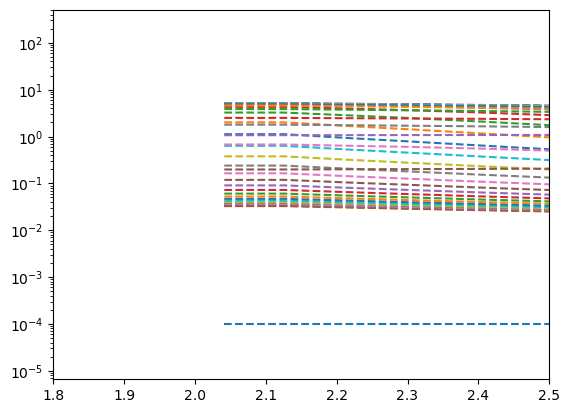

In [12]:
for it in range(len(data.t))[::5]:
    #plt.plot(data.grid.r[it,:]/c.au,(data.dust.a[it,:,4]))
    plt.plot(data.grid.r[it,:]/c.au,(data.dust.s.max[it,:]),"--")
plt.yscale("log")
plt.xlim(1.8,2.5)
plt.show()

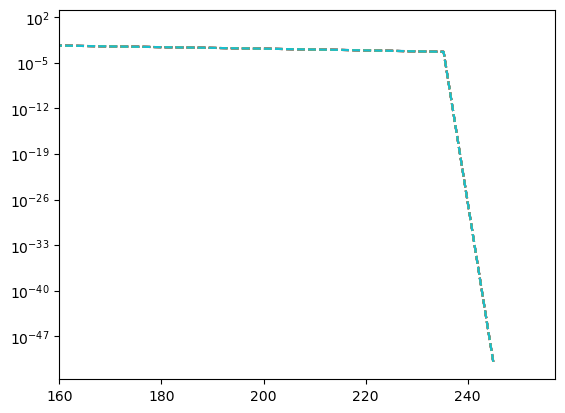

In [76]:
for it in range(len(data.t))[:10]:
    plt.plot(data.grid.r[it,:]/c.au,(data.dust.Sigma[it,:,1]),"--")
plt.yscale("log")
plt.xlim(160)
plt.show()

In [70]:
(data.dust.s.max[:,-1]*data.dust.Sigma[:,-1,1] == data.dust.s.max[:,-2]*data.dust.Sigma[:,-2,1]).all()

ValueError: operands could not be broadcast together with shapes (147,) (131,) 

In [73]:
(data.dust.Sigma[:,-2,1]).shape

(131,)

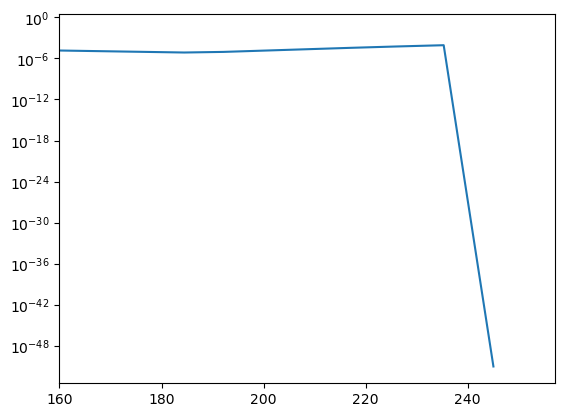

In [46]:
for it in range(len(data.t))[:1]:
    plt.plot(data.grid.r[it,:]/c.au,(data.dust.Sigma[it,:,0]))
plt.yscale("log")
plt.xlim(160)
plt.show()